In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Load data
df = pd.read_csv('fcc-forum-pageviews.csv', parse_dates=['date'], index_col='date')

# Clean data (remove top and bottom 2.5%)
lower = df['value'].quantile(0.025)
upper = df['value'].quantile(0.975)
df_clean = df[(df['value'] >= lower) & (df['value'] <= upper)]


In [1]:
def draw_line_plot():
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(df_clean.index, df_clean['value'], color='red', linewidth=1)
    ax.set_title('Daily freeCodeCamp Forum Page Views 5/2016-12/2019')
    ax.set_xlabel('Date')
    ax.set_ylabel('Page Views')
    plt.tight_layout()
    plt.show()


In [2]:
def draw_bar_plot():
    # Prepare data
    df_bar = df_clean.copy()
    df_bar['year'] = df_bar.index.year
    df_bar['month'] = df_bar.index.month_name()
    
    # Group and pivot
    df_grouped = df_bar.groupby(['year', 'month'])['value'].mean().unstack()
    # To keep month order
    months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                    'July', 'August', 'September', 'October', 'November', 'December']
    df_grouped = df_grouped[months_order]

    # Plot
    df_grouped.plot(kind='bar', figsize=(15, 7))
    plt.xlabel('Years')
    plt.ylabel('Average Page Views')
    plt.legend(title='Months')
    plt.tight_layout()
    plt.show()


In [3]:
def draw_box_plot():
    df_box = df_clean.copy()
    df_box.reset_index(inplace=True)
    df_box['year'] = df_box['date'].dt.year
    df_box['month'] = df_box['date'].dt.strftime('%b')
    df_box['month_num'] = df_box['date'].dt.month

    # Sort by month number
    df_box = df_box.sort_values('month_num')

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Year-wise Box Plot
    sns.boxplot(x='year', y='value', data=df_box, ax=axes[0])
    axes[0].set_title('Year-wise Box Plot (Trend)')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Page Views')

    # Month-wise Box Plot
    sns.boxplot(x='month', y='value', data=df_box, ax=axes[1])
    axes[1].set_title('Month-wise Box Plot (Seasonality)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('Page Views')

    plt.tight_layout()
    plt.show()


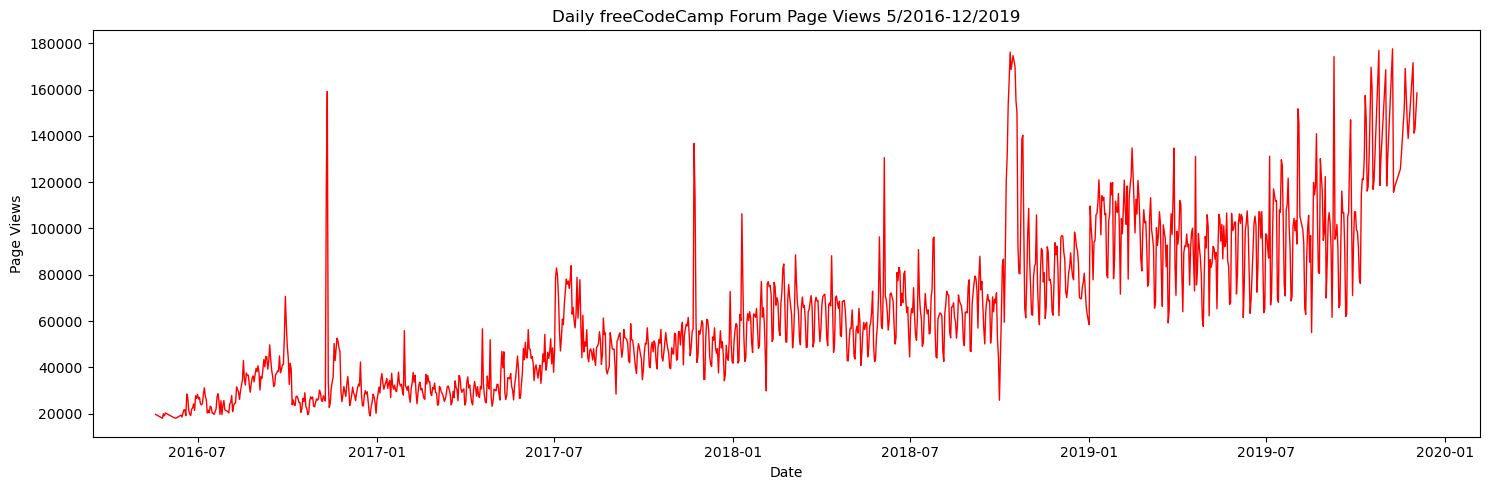

In [7]:
draw_line_plot()



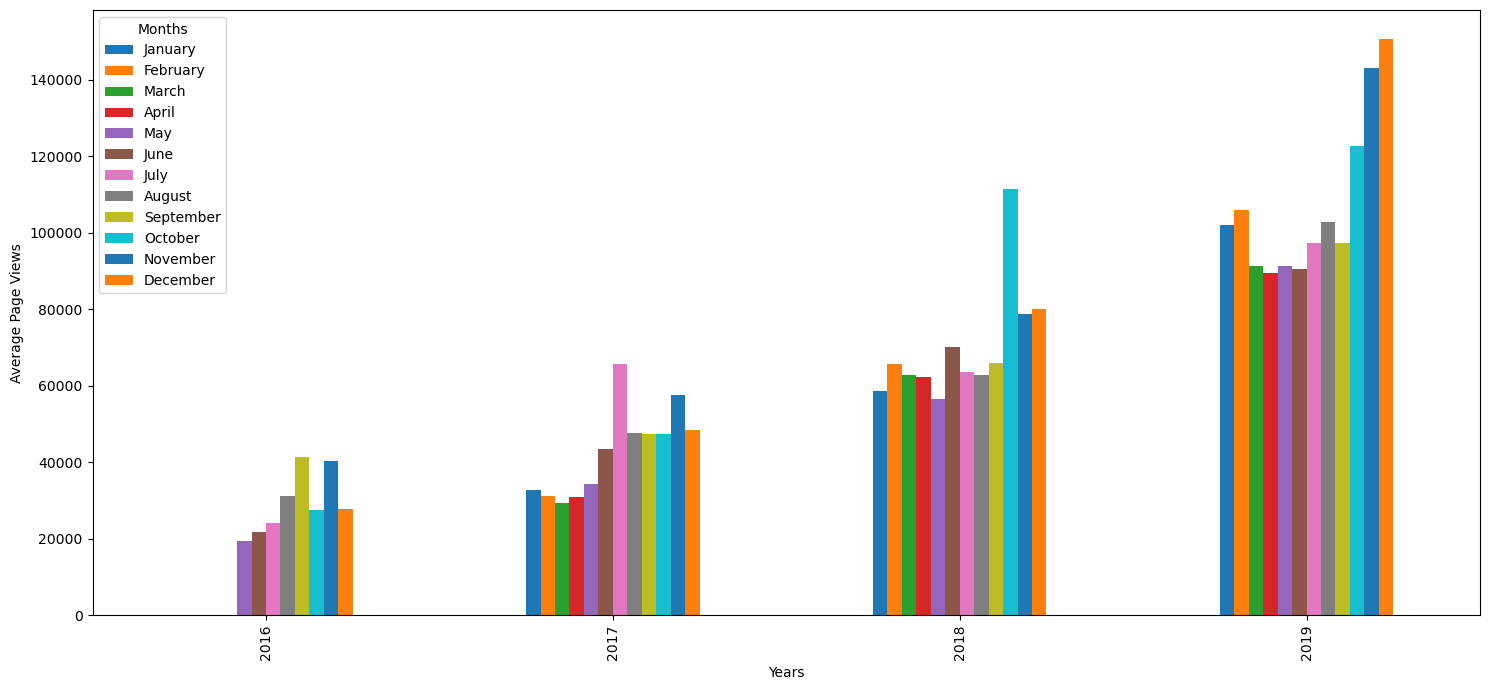

In [8]:
draw_bar_plot()


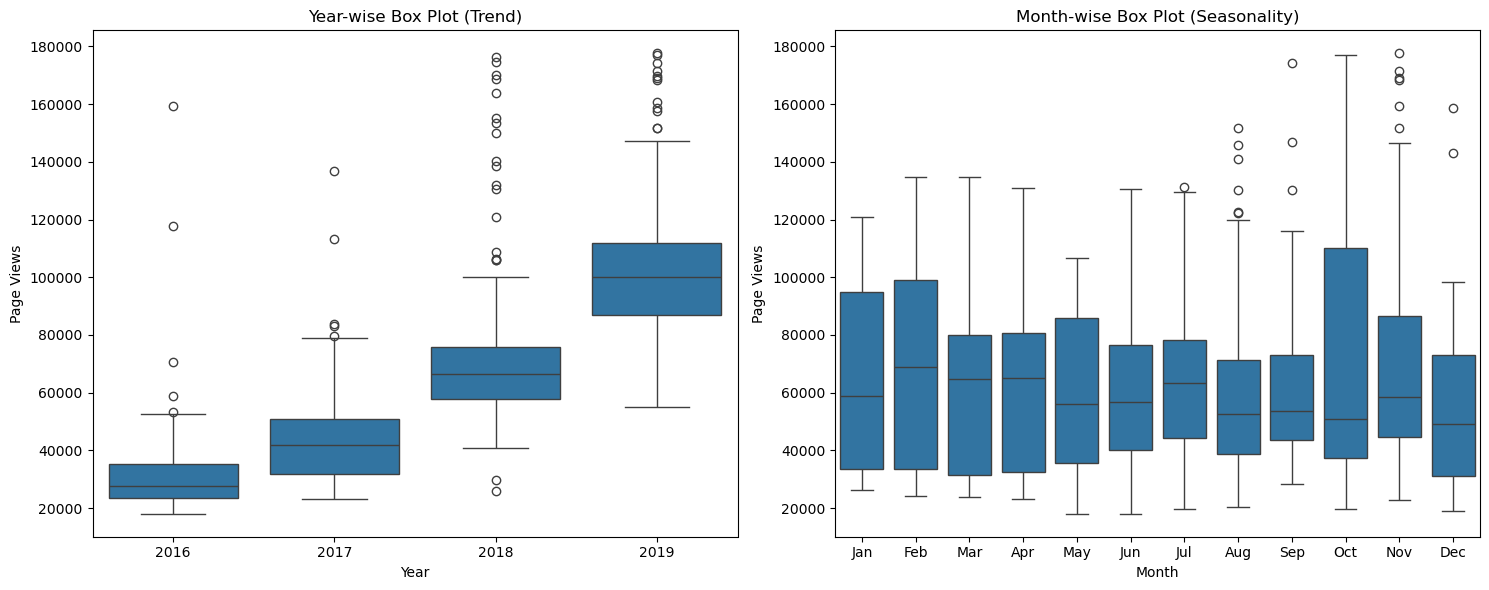

In [9]:
draw_box_plot()